IMPORTING LIBRARIES

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

LOAD DATASET

In [20]:
df = pd.read_csv("women_public_space_survey_550.csv")
print(df.head())

  Age_Group Travel_Frequency Type_of_Public_Place Time_of_Visit Crowd_Level  \
0     25-35            Daily      Restaurant/Cafe       Morning    1000-10k   
1     25-35           Weekly     Public Bus/Train     Afternoon       <1000   
2     15-25            Daily        Market/Bazaar       Evening  1000-10000   
3     35-45          Monthly          Park/Garden     Afternoon  1000-10000   
4     15-25            Daily        ATM/Bank Area       Evening       <1000   

  Mode_of_Transport Safe_Visiting_Alone Avoid_Going_Out_At_Night  \
0               Cab                  No                       No   
1               Cab                  No                      Yes   
2              Auto                 Yes                      Yes   
3             Train                 Yes                      Yes   
4             Train                  No                       No   

  Experienced_Harassment Lighting_Condition CCTV_Available  \
0                    Yes            Average           

In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age_Group                 550 non-null    object
 1   Travel_Frequency          550 non-null    object
 2   Type_of_Public_Place      550 non-null    object
 3   Time_of_Visit             550 non-null    object
 4   Crowd_Level               550 non-null    object
 5   Mode_of_Transport         535 non-null    object
 6   Safe_Visiting_Alone       550 non-null    object
 7   Avoid_Going_Out_At_Night  550 non-null    object
 8   Experienced_Harassment    550 non-null    object
 9   Lighting_Condition        550 non-null    object
 10  CCTV_Available            550 non-null    object
 11  Security_in_Public_Place  550 non-null    object
dtypes: object(12)
memory usage: 51.7+ KB
None


DATA CLEANING

In [22]:
df['Lighting_Condition'] = df['Lighting_Condition'].replace('avg','Average')
df['Crowd_Level'] = df['Crowd_Level'].replace('1000-10k','1000-10000')

df['Mode_of_Transport'] = df['Mode_of_Transport'].fillna('Unknown')

CONVERT CATEGORICAL VARIABLE TO NUMERIC

In [23]:
df['Safe_Visiting_Alone'] = df['Safe_Visiting_Alone'].map({'Yes':1,'No':0})

df['Avoid_Going_Out_At_Night'] = df['Avoid_Going_Out_At_Night'].map({'Yes':0,'No':1})

df['Experienced_Harassment'] = df['Experienced_Harassment'].map({'Yes':0,'No':1})

df['CCTV_Available'] = df['CCTV_Available'].map({'Yes':1,'No':0})

df['Security_in_Public_Place'] = df['Security_in_Public_Place'].map({'Yes':1,'No':0})

df['Lighting_Condition'] = df['Lighting_Condition'].map({
    'Poor':0,
    'Average':1,
    'Good':2
})

In [24]:
print(df.head())

  Age_Group Travel_Frequency Type_of_Public_Place Time_of_Visit Crowd_Level  \
0     25-35            Daily      Restaurant/Cafe       Morning  1000-10000   
1     25-35           Weekly     Public Bus/Train     Afternoon       <1000   
2     15-25            Daily        Market/Bazaar       Evening  1000-10000   
3     35-45          Monthly          Park/Garden     Afternoon  1000-10000   
4     15-25            Daily        ATM/Bank Area       Evening       <1000   

  Mode_of_Transport  Safe_Visiting_Alone  Avoid_Going_Out_At_Night  \
0               Cab                    0                         1   
1               Cab                    0                         0   
2              Auto                    1                         0   
3             Train                    1                         0   
4             Train                    0                         1   

   Experienced_Harassment  Lighting_Condition  CCTV_Available  \
0                       0              

CALCULATE SAFETY SCORE

In [25]:
df['Infrastructure_Score'] = (
    df['CCTV_Available'] +
    df['Security_in_Public_Place'] +
    df['Lighting_Condition']
)

df['Perception_Score'] = (
    df['Safe_Visiting_Alone'] +
    df['Avoid_Going_Out_At_Night'] +
    df['Experienced_Harassment']
)

df['Safety_Score'] = df['Infrastructure_Score'] + df['Perception_Score']

Outlier Detection and Removal (IQR Method)

In [26]:
features = ['Infrastructure_Score','Perception_Score']

Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)

IQR = Q3 - Q1

df_clean = df[
    ~((df[features] < (Q1 - 1.5 * IQR)) |
      (df[features] > (Q3 + 1.5 * IQR))
     ).any(axis=1)
]

print("Original size:", df.shape)
print("After outlier removal:", df_clean.shape)


Original size: (550, 15)
After outlier removal: (550, 15)


Compute Average Scores for Each Public Place

In [27]:
place_data = df_clean.groupby('Type_of_Public_Place').agg({
    'Infrastructure_Score':'mean',
    'Perception_Score':'mean',
    'Safety_Score':'mean'
}).reset_index()

print(place_data)

         Type_of_Public_Place  Infrastructure_Score  Perception_Score  \
0               ATM/Bank Area              2.000000          1.375000   
1                    Bus Stop              2.083333          1.583333   
2       Cinema Hall/Multiplex              1.964286          1.642857   
3   College/University Campus              2.117647          1.294118   
4          Gym/Fitness Center              2.033333          1.533333   
5             Hospital/Clinic              2.347826          1.173913   
6        Library/Study Center              2.153846          1.730769   
7               Market/Bazaar              2.366667          1.266667   
8               Metro Station              1.878788          1.545455   
9       Office/Workplace Area              1.761905          1.238095   
10                Park/Garden              2.304348          1.391304   
11               Parking Area              2.000000          1.454545   
12           Public Bus/Train              2.000000

Standardize Features

In [28]:
scaler = StandardScaler()

X = scaler.fit_transform(
    place_data[['Infrastructure_Score','Perception_Score']]
)

K-Means Clustering

In [29]:
kmeans = KMeans(n_clusters=3, random_state=42)

place_data['kmeans'] = kmeans.fit_predict(X)

Scatter Plot of KMeans Clusters

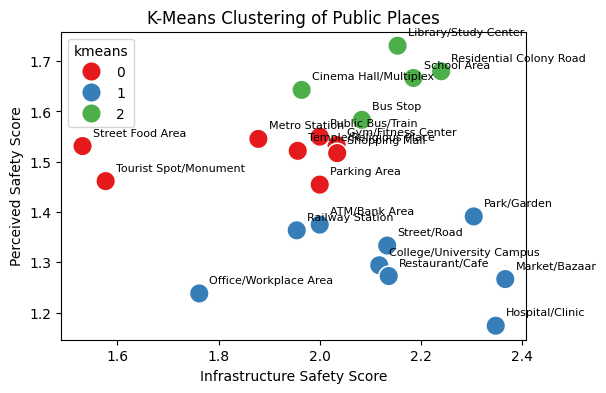

In [30]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=place_data['Infrastructure_Score'],
    y=place_data['Perception_Score'],
    hue=place_data['kmeans'],
    palette='Set1',
    s=200
)

for i,row in place_data.iterrows():
    plt.text(row['Infrastructure_Score']+0.02,
             row['Perception_Score']+0.02,
             row['Type_of_Public_Place'],
             fontsize=8)

plt.title("K-Means Clustering of Public Places")

plt.xlabel("Infrastructure Safety Score")
plt.ylabel("Perceived Safety Score")

plt.show()

Hierarchical Clustering (Ward Method)

In [51]:
ward = AgglomerativeClustering(n_clusters=3, linkage='ward')

place_data['ward'] = ward.fit_predict(X)

Ward Dendrogram

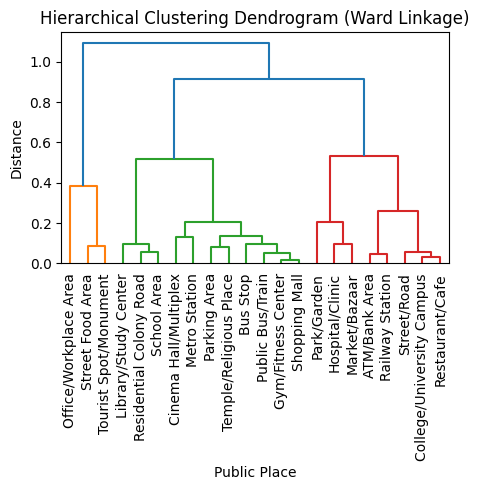

In [52]:
linked = linkage(
    place_data[['Infrastructure_Score','Perception_Score']],
    method='ward'
)

plt.figure(figsize=(5,3))

dendrogram(
    linked,
    labels=place_data['Type_of_Public_Place'].values,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Public Place")
plt.ylabel("Distance")

plt.show()

Average Linkage Clustering

In [53]:
avg = AgglomerativeClustering(n_clusters=3, linkage='average')

place_data['avg'] = avg.fit_predict(X)

Average Dendogram

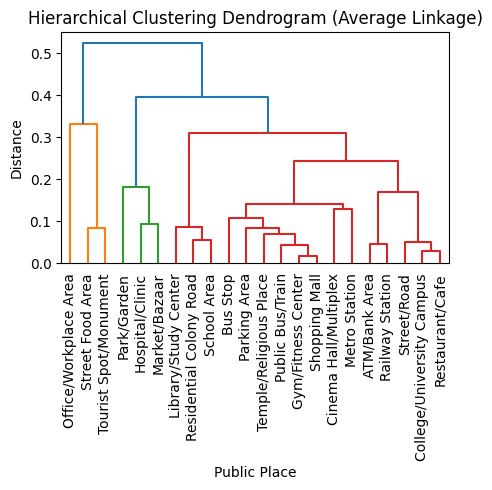

In [54]:
linked_avg = linkage(
    place_data[['Infrastructure_Score','Perception_Score']],
    method='average'
)

plt.figure(figsize=(5,3))

dendrogram(
    linked_avg,
    labels=place_data['Type_of_Public_Place'].values,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Public Place")
plt.ylabel("Distance")

plt.show()

Ensemble Clustering

In [55]:
cluster_cols = ['kmeans','ward','avg']

place_data['final_cluster'] = place_data[cluster_cols].mode(axis=1)[0]

In [56]:
print(place_data[['Type_of_Public_Place','kmeans','ward','avg','final_cluster']])

         Type_of_Public_Place  kmeans  ward  avg  final_cluster
0               ATM/Bank Area       1     0    1            1.0
1                    Bus Stop       2     2    2            2.0
2       Cinema Hall/Multiplex       2     2    2            2.0
3   College/University Campus       1     1    1            1.0
4          Gym/Fitness Center       0     2    2            2.0
5             Hospital/Clinic       1     1    1            1.0
6        Library/Study Center       2     2    2            2.0
7               Market/Bazaar       1     1    1            1.0
8               Metro Station       0     2    2            2.0
9       Office/Workplace Area       1     0    0            0.0
10                Park/Garden       1     1    1            1.0
11               Parking Area       0     2    1            0.0
12           Public Bus/Train       0     2    2            2.0
13            Railway Station       1     0    1            1.0
14    Residential Colony Road       2   

Scatter Plot of Final Clusters

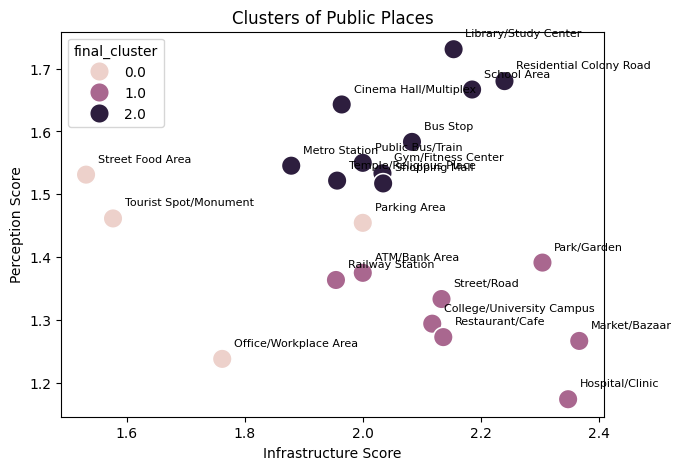

In [57]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='Infrastructure_Score',
    y='Perception_Score',
    hue='final_cluster',
    s=200,
    data=place_data
)

for i,row in place_data.iterrows():
    plt.text(
        row['Infrastructure_Score']+0.02,
        row['Perception_Score']+0.02,
        row['Type_of_Public_Place'],
        fontsize=8
    )

plt.title("Clusters of Public Places")

plt.xlabel("Infrastructure Score")
plt.ylabel("Perception Score")

plt.show()

Safety Score Bar Chart

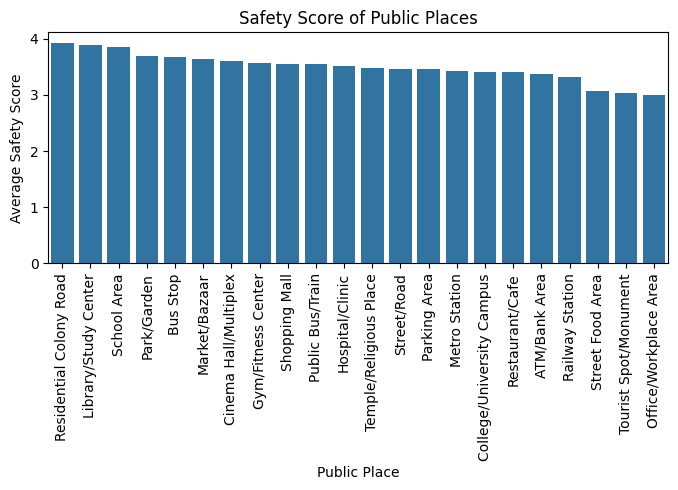

In [62]:
place_safety = place_data.sort_values(by='Safety_Score',ascending=False)

plt.figure(figsize=(8,3))

sns.barplot(
    x='Type_of_Public_Place',
    y='Safety_Score',
    data=place_safety
)

plt.xticks(rotation=90)

plt.title("Safety Score of Public Places")

plt.xlabel("Public Place")

plt.ylabel("Average Safety Score")

plt.show()

Silhouette Score Evaluation

In [46]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, place_data['kmeans'])

print("Silhouette Score:", score)

Silhouette Score: 0.33092388194857536
